In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

# In Google Drive, right click the folder shared with you and click Organize -> Add a Shortcut --> MyDrive (Add)
data_path = '/content/drive/MyDrive/AI4ALL_finalproject_data/'
print(os.listdir(data_path))

Mounted at /content/drive
['Fake.csv', 'True.csv', 'liar_test.tsv', 'liar_train.tsv', 'liar_validation.tsv']


In [ ]:
import pandas as pd
true = pd.read_csv(data_path + "True.csv")
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake = pd.read_csv(data_path + "Fake.csv")
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


## Unsupervised Exploration

### Data Cleaning
Are there any distractors you already see in the text that you want to clean up?

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

true['label'] = 'real'
fake['label'] = 'fake'
df = pd.concat([true, fake], ignore_index=True)

JUNK_WORDS = {'getty', 'flickr', 'reuters', 'cdata', 'filessupport', 'wiretv',
              'belowfeatured', 'somodevillagetty', 'wonggetty', 'angerergetty',
              'screenshot', 'subscribing', 'nyp', 'wfb', 'acr', 'js', 'wikimedia', 'screengrab', 'rascalsjoin', 'mediamaniacs'}

#Can someone chek if this will work or be useful:
#STOP_WORDS = set([
#    'a', 'an', 'and', 'are', 'as', 'at', 'be', 'but', 'by',
#    'for', 'if', 'in', 'into', 'is', 'it', 'no', 'not', 'of', 'on',
#    'or', 'such', 'that', 'the', 'their', 'then', 'there', 'these',
#    'they', 'this', 'to', 'was', 'will', 'with'
#])

def clean_text(text):
    text = re.sub(r'^[A-Z\s]+\(Reuters\)\s*-\s*', '', text)
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\b\w{1}\b', '', text)
    text = ' '.join(w for w in text.split() if w not in JUNK_WORDS)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df['clean_title'] = df['title'].apply(clean_text)

true = df[df['label'] == 'real']
fake = df[df['label'] == 'fake']

### Clustering
What are these articles about? Do clusters distribute evenly across real and fake news? Is topic an important feature of whether news is real or fake?

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Convert the text to TF-IDF vectors
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])

# Cluster the articles using KMeans
numberOfClusters = 5
kmeans = KMeans(n_clusters=numberOfClusters, random_state=42)
kmeans.fit(X)
df['cluster'] = kmeans.labels_

# For each cluster, print the top words and the real vs fake breakdown
feature_names = vectorizer.get_feature_names_out()

for i in range(numberOfClusters):
    cluster_df = df[df['cluster'] == i]

    # Top words
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]

    # Real vs fake breakdown
    breakdown = cluster_df['label'].value_counts()

    print(f"\nCluster {i}:")
    print(f"  Top words: {top_words}")
    print(f"  Articles: {len(cluster_df)}")
    print(f"  {breakdown.to_dict()}")


Cluster 0:
  Top words: ['said', 'government', 'minister', 'united', 'state', 'president', 'party', 'iran', 'eu', 'military']
  Articles: 10852
  {'real': 10181, 'fake': 671}

Cluster 1:
  Top words: ['trump', 'donald', 'said', 'clinton', 'president', 'campaign', 'republican', 'just', 'hillary', 'people']
  Articles: 9189
  {'fake': 7085, 'real': 2104}

Cluster 2:
  Top words: ['korea', 'north', 'korean', 'nuclear', 'china', 'missile', 'south', 'said', 'pyongyang', 'sanctions']
  Articles: 1140
  {'real': 1032, 'fake': 108}

Cluster 3:
  Top words: ['clinton', 'people', 'said', 'police', 'hillary', 'obama', 'just', 'like', 'black', 'trump']
  Articles: 16293
  {'fake': 14350, 'real': 1943}

Cluster 4:
  Top words: ['said', 'house', 'senate', 'trump', 'tax', 'republican', 'president', 'republicans', 'court', 'trumps']
  Articles: 7424
  {'real': 6157, 'fake': 1267}


### Log-Odds
What kinds of language is common in fake news but rare in real news? And vice versa? How would you describe the language of fake news?

Top 20 words associated with fake news: [('henningsen', 5.963579343618446), ('finicum', 5.820082930352362), ('reilly', 5.709322655031817), ('hesher', 5.4638318050256105), ('uninterruptible', 5.356586274672012), ('philosophers', 5.3471075307174685), ('fcking', 5.332718793265369), ('spore', 5.327876168789581), ('savants', 5.327876168789581), ('moralists', 5.327876168789581), ('evangelists', 5.3230099791384085), ('masochists', 5.3230099791384085), ('bundy', 5.197114861038874), ('subscribe', 5.157137753085257), ('boiler', 5.126935749792416), ('fck', 4.997212273764115), ('antifa', 4.774068722449905), ('sht', 4.727387818712341), ('aka', 4.705015520957808), ('hilarious', 4.702750514326955)]

Top 20 words associated with real news: [('rakhine', -6.799055862058796), ('rohingya', -6.526982783464344), ('puigdemont', -6.470799503782602), ('myanmar', -6.324717321102222), ('zuma', -6.267200548541362), ('fdp', -6.238324625039508), ('suu', -6.202535517187923), ('kyi', -6.19644412779452), ('hariri', -6

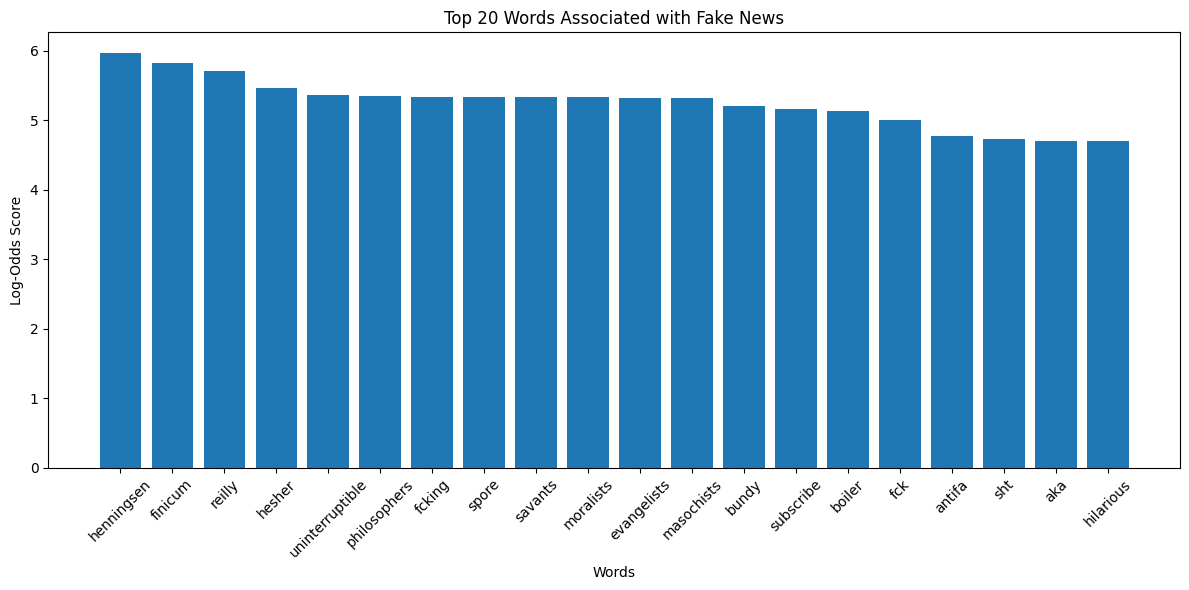

In [ ]:
from collections import Counter
import math
import matplotlib.pyplot as plt

# Count word frequencies separately for real and fake articles
real_words = " ".join(true['clean_text']).split()
fake_words = " ".join(fake['clean_text']).split()

real_counts = Counter(real_words)
fake_counts = Counter(fake_words)

# Calculate log-odds for each word
log_odds = {}

all_words = set(real_counts.keys()).union(set(fake_counts.keys()))
all_words = {w for w in all_words if (real_counts.get(w, 0) + fake_counts.get(w, 0)) >= 200}  # ← add back

for word in all_words:
    fake_count = fake_counts.get(word, 0) + 1
    real_count = real_counts.get(word, 0) + 1
    log_odds[word] = math.log(fake_count / real_count)

# Print top 20 words
top_fake = sorted(log_odds.items(), key=lambda x: x[1], reverse=True)[:20]
top_real = sorted(log_odds.items(), key=lambda x: x[1])[:20]

print(f"Top 20 words associated with fake news: {top_fake}")
print(f"\nTop 20 words associated with real news: {top_real}")

# Bar chart
words = [word for word, score in top_fake]
scores = [score for word, score in top_fake]

plt.figure(figsize=(12,6))
plt.bar(words, scores)
plt.xticks(rotation=45)
plt.title("Top 20 Words Associated with Fake News")
plt.xlabel("Words")
plt.ylabel("Log-Odds Score")
plt.tight_layout()  # ← prevents x labels from getting cut off
plt.show()

## Supervised Training

### Data Cleaning
Are there any distractors you already see in the text that you want to clean up? Anything you learned from unsupervised exploration that informs these cleaning choices?

In [ ]:
# TODO: Create a numeric label column (fake=1, real=0)
df['label_num'] = (df['label'] == 'fake').astype(int)


# TODO: Based on what you found in Part 1, engineer at least 2 new features
# Ideas: exclamation point count, ALL CAPS word count, title length, question marks...
# Add them as new columns in df

df['exclamations'] = df['text'].apply(lambda x: x.count('!'))
df['questions'] = df['text'].apply(lambda x: x.count('?'))
df['caps_words'] = df['text'].apply(lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 1))

print(df.groupby('label')[['exclamations', 'questions', 'caps_words']].mean())

# TODO: Print the average of your new features grouped by real vs fake
# Do they already look different between the two classes?

       exclamations  questions  caps_words
label                                     
fake       0.722968   1.205656    6.620502
real       0.061913   0.100761    5.746743


### Rule-Based Methods
Can you use Naive Bayes or dictionary methods to pick out the lexical patterns that might predict that an article is fake news?

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

true['label'] = 0   # real
fake['label'] = 1   # fake

df = pd.concat([true, fake])

# TODO: Split the data into train and test sets
X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Vectorize the text using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# TODO: Train a Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# TODO: Print the classification report
# Look at precision and recall: which errors does the model make more?
# What does it mean in the real world if a real article gets flagged as fake?
y_pred = nb.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

/tmp/ipykernel_5054/178347058.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  true['label'] = 0   # real
/tmp/ipykernel_5054/178347058.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fake['label'] = 1   # fake


              precision    recall  f1-score   support

           0       0.93      0.96      0.94      4330
           1       0.96      0.93      0.94      4650

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



### Build a Classifier
Use the actual real/fake labels in the dataset to train a RoBERTa classifier to help you predict.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# TODO: Train a Logistic Regression classifier
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train)
y_pred_lr = logreg.predict(X_test_tfidf)

# TODO: Print classification report and compare to Naive Bayes
print(classification_report(y_test, y_pred_lr))

# TODO: Look at coefficients to find words most predictive of fake news
feature_names = vectorizer.get_feature_names_out()
coefficients = logreg.coef_[0]

top_fake_indices = coefficients.argsort()[-20:][::-1]
top_real_indices = coefficients.argsort()[:20]

print("Top 20 words predictive of fake news:")
print([feature_names[i] for i in top_fake_indices])

print("\nTop 20 words predictive of real news:")
print([feature_names[i] for i in top_real_indices])

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4330
           1       0.99      0.98      0.98      4650

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980

Top 20 words predictive of fake news:
['just', 'image', 'obama', 'don', 'gop', 'america', 'didn', 'mr', 'wire', 'doesn', 've', 'like', 'hillary', 'trump', 'american', 'rep', 'images', 'll', 'video', 'isn']

Top 20 words predictive of real news:
['said', 'trumps', 'wednesday', 'tuesday', 'thursday', 'friday', 'monday', 'minister', 'republican', 'reporters', 'told', 'dont', 'presidential', 'nov', 'obamas', 'comment', 'statement', 'edt', 'im', 'spokesman']


#### Validate Your Model
80/20 split train/test? Cross validation?

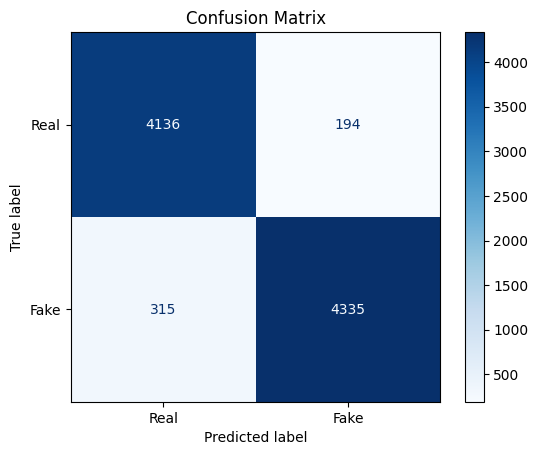

[[4136  194]
 [ 315 4335]]
False Positives:  194


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# TODO: Plot a confusion matrix for your best model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(cm)
# TODO: Which cell represents 'predicted fake, actually real'?
# cm[0][1]
# How many articles fell there? What's the real-world impact of that?
print("False Positives: ", cm[0][1])

## Ensemble Modeling
Use the LIAR dataset to model false-hood.

#### Explore the data
What are the levels of false-hood? How do they relate to speaker, topic, and setting? What can you tell about the rhetoric?

In [ ]:
liar = pd.read_csv(data_path + "liar_train.tsv", sep="\t", header=None,
                   names=['id', 'label', 'statement', 'subject', 'speaker', 'job',
                          'state', 'party', 'barely_true', 'false', 'half_true',
                          'mostly_true', 'pants_fire', 'context'])
liar.head()

,id,label,statement,subject,speaker,job,state,party,barely_true,false,half_true,mostly_true,pants_fire,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [ ]:
# TODO: Print the distribution of label values
# What are the 6 levels of truthfulness?
print(liar['label'].value_counts())

# TODO: Map labels to a simpler binary: true-ish vs false-ish
liar['binary_label'] = liar['label'].map({
    'true': 1,
    'mostly-true': 1,
    'half-true': 1,
    'barely-true': 0,
    'false': 0,
    'pants-fire': 0
})
print(liar[['label', 'binary_label']].head())
# TODO: Explore the data -- which speakers, parties, or topics
# appear most often? Does the true/false split vary by party?
print("Top speakers: ")
print(liar['speaker'].value_counts().head(10))
print("Top parties: ")
print(liar['party'].value_counts())
print("Top topics: ")
print(liar['subject'].value_counts().head(10))
party_truth = liar.groupby('party')['binary_label'].mean()

print(liar.shape)
print(liar.columns.tolist())

label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64
         label  binary_label
0        false             0
1    half-true             1
2  mostly-true             1
3        false             0
4    half-true             1
Top speakers: 
speaker
barack-obama       488
donald-trump       273
hillary-clinton    239
mitt-romney        176
scott-walker       149
john-mccain        148
rick-perry         142
chain-email        142
marco-rubio        117
rick-scott         115
Name: count, dtype: int64
Top parties: 
party
republican                      4497
democrat                        3336
none                            1744
organization                     219
independent                      147
newsmaker                         56
libertarian                       40
activist                          39
journalist                        38
columnist                         35
talk-

### Find Similarity
Use embeddings to see when sentences of your fake news articles are too similar to factually false statements.

In [ ]:
# !pip install sentence-transformers -q
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

sentence_model = SentenceTransformer('all-MiniLM-L6-v2')

# Get embeddings for known false statements from LIAR
false_statements = liar[liar['binary_label'] == 0]['statement'].dropna().head(500).tolist()
false_embeddings = sentence_model.encode(false_statements, show_progress_bar=True)

# TODO: Pick one fake and one real article from df
# Split each into sentences and encode them
fake_article = fake.iloc[0]['text']
real_article = true.iloc[0]['text']
fake_sentences = fake_article.split('.')
real_sentences = real_article.split('.')
fake_sentence_embeddings = sentence_model.encode(fake_sentences)
real_sentence_embeddings = sentence_model.encode(real_sentences)

# TODO: For each sentence, find the most similar false statement using cosine_similarity
# Print the sentence, the most similar false claim, and the similarity score
print("FAKE ARTICLE COMPARISON:\n")
fake_high_similarity = 0

for i, sentence_embedding in enumerate(fake_sentence_embeddings):
    similarities = cosine_similarity(
        [sentence_embedding],
        false_embeddings
    )[0]

    best_match_index = similarities.argmax()
    best_score = similarities[best_match_index]

    print("Sentence:", fake_sentences[i])
    print("Most similar false claim:", false_statements[best_match_index])
    print("Similarity Score:", best_score)
    print()

    if best_score > 0.7:
        fake_high_similarity += 1

print("REAL ARTICLE COMPARISON:\n")
real_high_similarity = 0

for i, sentence_embedding in enumerate(real_sentence_embeddings):
    similarities = cosine_similarity(
        [sentence_embedding],
        false_embeddings
    )[0]

    best_match_index = similarities.argmax()
    best_score = similarities[best_match_index]

    print("Sentence:", real_sentences[i])
    print("Most similar false claim:", false_statements[best_match_index])
    print("Similarity Score:", best_score)
    print()

    if best_score > 0.7:
        real_high_similarity += 1
# TODO: Does the fake article have more high-similarity sentences than the real one?
print("Fake article high-similarity sentences:", fake_high_similarity)
print("Real article high-similarity sentences:", real_high_similarity)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

FAKE ARTICLE COMPARISON:

Sentence: Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that
Most similar false claim: Says Donald Trump doesnt make a thing in America.
Similarity Score: 0.40150663

Sentence:  Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media
Most similar false claim: When President, then candidate, Obama was asked to disclose some of his donors because there was suspicion of their being the foreign source of money into his campaign, they refused to do it.
Similarity Score: 0.4082092

Sentence:   The former reality show star had just one job to do and he couldn t do it
Most similar false claim: Mary Burkes record: 130,000 fewer jobs.
Similarity Score: 0.34487975

Sentence:  As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted
Most

Is there a threshold at which "too similar" means the sentence in the news article is also false? What happens when too many sentences in the article trip this threshold?

Average suspicious fraction (fake): 0.012180236885887118
Average suspicious fraction (real): 0.041450592975413814


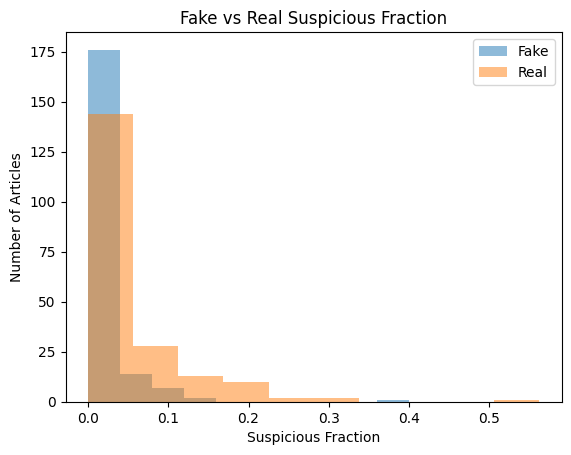

In [ ]:
fake_fractions = []
real_fractions = []
THRESHOLD = 0.55

for article in fake['text'].head(200):
    sentences = [s for s in article.split('.') if len(s.strip()) > 5]
    if not sentences:
        continue
    sentence_embeddings = sentence_model.encode(sentences, batch_size=64)
    similarities = cosine_similarity(sentence_embeddings, false_embeddings)
    suspicious_count = (similarities.max(axis=1) > THRESHOLD).sum()
    fake_fractions.append(suspicious_count / len(sentences))

for article in true['text'].head(200):
    sentences = [s for s in article.split('.') if len(s.strip()) > 5]
    if not sentences:
        continue
    sentence_embeddings = sentence_model.encode(sentences, batch_size=64)
    similarities = cosine_similarity(sentence_embeddings, false_embeddings)
    suspicious_count = (similarities.max(axis=1) > THRESHOLD).sum()
    real_fractions.append(suspicious_count / len(sentences))

print("Average suspicious fraction (fake):", sum(fake_fractions)/len(fake_fractions))
print("Average suspicious fraction (real):", sum(real_fractions)/len(real_fractions))

plt.hist(fake_fractions, alpha=0.5, label="Fake")
plt.hist(real_fractions, alpha=0.5, label="Real")
plt.xlabel("Suspicious Fraction")
plt.ylabel("Number of Articles")
plt.title("Fake vs Real Suspicious Fraction")
plt.legend()
plt.show()

### Model Truthiness

#### Train a RoBERTa model
Since there are levels of "false", turn these into numbers and train a regression model. Or, collapse them into just 2 labels true/false and train a binary classifier again.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset
import torch
import numpy as np
from sklearn.metrics import classification_report

SAVE_MODEL = True  # set to False to skip saving

liar_train = pd.read_csv(data_path + 'liar_train.tsv', sep='\t', header=None)
liar_test = pd.read_csv(data_path + 'liar_test.tsv', sep='\t', header=None)

train_cols = ['id', 'label', 'statement', 'subject', 'speaker', 'job', 'state', 'party', 'true_counts', 'mostly_true', 'half_true', 'barely_true', 'false_counts', 'pants_fire']

liar_train.columns = train_cols
liar_test.columns = train_cols

# Collapse labels into binary true/false
def binarize_label(label):
    if label in ['true', 'mostly-true', 'half-true']:
        return 1
    else:  # barely-true, false, pants-fire
        return 0

liar_train['binary_label'] = liar_train['label'].apply(binarize_label)
liar_test['binary_label'] = liar_test['label'].apply(binarize_label)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

# Dataset class
class LiarDataset(Dataset):
    def __init__(self, df):
        self.encodings = tokenizer(df['statement'].tolist(), truncation=True, padding=True, max_length=128)
        self.labels = df['binary_label'].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = LiarDataset(liar_train)
test_dataset = LiarDataset(liar_test)

# Load model
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

# Training arguments
training_args = TrainingArguments(
    output_dir='./roberta_liar',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    load_best_model_at_end=False,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

if SAVE_MODEL:
    trainer.save_model('./roberta_liar_saved')

# Evaluate
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = liar_test['binary_label'].tolist()

print(classification_report(y_true, y_pred, target_names=['false', 'true']))

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.684819,0.690768
2,0.695861,0.685182
3,0.691471,0.685111


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

       false       0.00      0.00      0.00       553
        true       0.56      1.00      0.72       714

    accuracy                           0.56      1267
   macro avg       0.28      0.50      0.36      1267
weighted avg       0.32      0.56      0.41      1267



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Validate Your Model
Use the liar_test.tsv file as your test set!

#### Apply to News Dataset
Apply your model to every sentence of your news articles.

Average truthiness score (fake): 0.5691896891593933
Average truthiness score (real): 0.5691820421814918


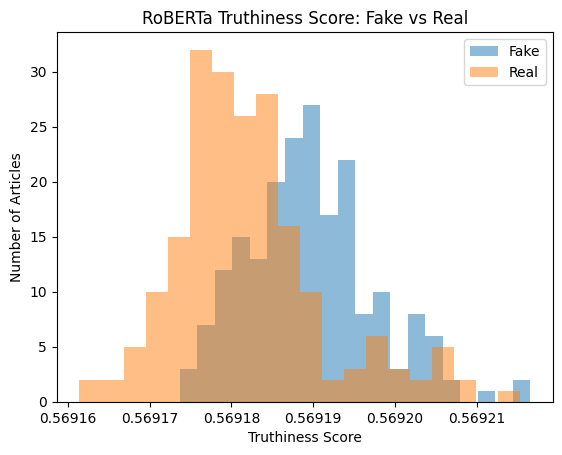

In [ ]:
from torch.nn.functional import softmax

def score_article(text, tokenizer, model, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.to(device)
    model.eval()
    sentences = [s.strip() for s in text.split('.') if len(s.strip()) > 5]
    if not sentences:
        return 0.5

    inputs = tokenizer(sentences, truncation=True, padding=True, max_length=128, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = softmax(outputs.logits, dim=1)[:, 1]  # probability of "true"
    return probs.mean().item()  # mean across sentences

# Score 200 fake and 200 real articles
fake_scores = [score_article(text, tokenizer, model) for text in fake['text'].head(200)]
real_scores = [score_article(text, tokenizer, model) for text in true['text'].head(200)]

print("Average truthiness score (fake):", sum(fake_scores) / len(fake_scores))
print("Average truthiness score (real):", sum(real_scores) / len(real_scores))

plt.hist(fake_scores, alpha=0.5, label='Fake', bins=20)
plt.hist(real_scores, alpha=0.5, label='Real', bins=20)
plt.xlabel('Truthiness Score')
plt.ylabel('Number of Articles')
plt.title('RoBERTa Truthiness Score: Fake vs Real')
plt.legend()
plt.show()

### Put it Together
You have a dictionary methods, binary classifiers of fake/real articles, and models that give you scores of truthiness for every sentence of your article. Can you consider all these signals together to get a better prediction of which article is fake?

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

sample_fake = df[df['label'] == 1].head(200).copy()
sample_real = df[df['label'] == 0].head(200).copy()
sample = pd.concat([sample_fake, sample_real], ignore_index=True)
labels = [1] * 200 + [0] * 200

def extract_linguistic(text):
    exclamations = text.count('!')
    questions = text.count('?')
    caps_words = sum(1 for w in text.split() if w.isupper() and len(w) > 1)
    avg_word_len = np.mean([len(w) for w in text.split()]) if text.split() else 0
    return [exclamations, questions, caps_words, avg_word_len]

linguistic_features = np.array([extract_linguistic(t) for t in sample['text']])
suspicious_features = np.array(fake_fractions + real_fractions).reshape(-1, 1)
truthiness_features = np.array(fake_scores + real_scores).reshape(-1, 1)

# TF-IDF: convert text to 5000 word-frequency features, then compress to 50 dimensions
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(sample['clean_text'])
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_features = svd.fit_transform(tfidf_matrix)

X = np.hstack([linguistic_features, suspicious_features, truthiness_features, tfidf_features])
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)

print("=== Ensemble Model===")
print(classification_report(y_test, y_pred, target_names=['real', 'fake']))

=== Ensemble Model===
              precision    recall  f1-score   support

        real       0.92      0.94      0.93        36
        fake       0.95      0.93      0.94        44

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80

